<div align="center">

# Replicating the Commission Reference Trajectories

Lennard Welslau\
lennard.welslau[at]gmail[dot]com\
September 2026

</div>

In [1]:
# Import libraries and modules
import numpy as np
import pandas as pd
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns, pd.options.display.max_rows = 100, 100
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# Import classes and data pipeline
from classes import StochasticDsaModel as DSA
from data_pipeline import read_country, EU27, REPO_ROOT
from data_pipeline.commission import load_prior_guidance

# Set autoreload
%load_ext autoreload
%autoreload 2

# TOC
1. **Background**: the Commission prior guidance calculation sheets
2. **Input data**: building a workbook from the Commission sheets
3. **Debt dynamics**: replicating the Commission adjustment scenario
4. **Reference trajectory**: replicating the required adjustment with `find_spb_binding(rules='commission')`
5. **All countries**: validation results
6. **Default rules vs. Commission rules**
7. **Notes on differences**
8. **Latest data**: default settings of the model

## Background

- Before member states submitted their medium-term fiscal-structural plans, the Commission transmitted *prior guidance*: a **reference trajectory** for countries with debt above 60% or a deficit above 3% of GDP, and **technical information** for the others.
- For each country, the Commission published a **calculation sheet** (Excel) on its fiscal surveillance pages. The sheets contain the Commission's inputs (forecast, market expectations from Bloomberg, debt structure, ageing costs, stock-flow adjustments) and a simplified Excel version of its Stata model.
- The `data_pipeline` downloads these sheets and maps them to the model inputs. Running the model on these inputs allows a direct comparison with the Commission results.
- The 2024 guidance is based on the Commission 2024 spring forecast for most countries (autumn 2024 for AT, BE, BG, LT; spring 2025 for DE). Later guidance was issued for HU (updated), IE and NL (autumn 2025) and CZ (spring 2026).

## Input data

- `build_inputs(mode='commission')` downloads the calculation sheets (saved in `data/RawData/commission_prior_guidance`) and builds an input workbook with **all inputs taken from the Commission sheets**.
- The resulting workbooks `dsa_inputs_commission_2024.xlsx` and `dsa_inputs_commission_latest.xlsx` are included in `data/InputData`. Each country sheet documents the source of every value; user assumptions can be added in the *Overrides* sheet.
- The workbook also carries the settings needed for replication, e.g. the EDP status in T, the last forecast year, and the multiplier specification (Commission output gap rule, multiplier of 0.75 in 2024 guidance and 0.6 in guidance issued from 2025).

In [2]:
# Rebuild the workbook from the Commission sheets (downloads missing sheets and historical shock data)
# from data_pipeline.build import build_inputs
# build_inputs(mode='commission', prior_guidance='2024')

series, params = read_country('dsa_inputs_commission_2024.xlsx', 'FRA')
pd.Series(params).to_frame('FRA')

,FRA
REFERENCE_YEAR,"2,024.00"
LAST_FORECAST_YEAR,"2,025.00"
EXCESSIVE_DEFICIT_PROCEDURE,1.00
FISCAL_MULTIPLIER,0.75
FISCAL_MULTIPLIER_PERSISTENT,0.00
BUDGET_BALANCE_ELASTICITY,0.63
DEBT_ST_SHARE,0.10
DEBT_LT_MATURING_SHARE,0.08
DEBT_LT_MATURING_AVG_SHARE,0.08
DEBT_DOMESTIC_SHARE,1.00


In [3]:
series.loc[2023:2034, ['DEBT_RATIO', 'STRUCTURAL_PRIMARY_BALANCE', 'REAL_GDP_GROWTH', 'POTENTIAL_GDP_GROWTH',
                        'GDP_DEFLATOR_PCH', 'INTEREST_RATE_LT', 'INTEREST_RATE_ST', 'STOCK_FLOW_RATIO', 'AGEING_COST']]

,DEBT_RATIO,STRUCTURAL_PRIMARY_BALANCE,REAL_GDP_GROWTH,POTENTIAL_GDP_GROWTH,GDP_DEFLATOR_PCH,INTEREST_RATE_LT,INTEREST_RATE_ST,STOCK_FLOW_RATIO,AGEING_COST
YEAR,,,,,,,,,
2023,110.64,-3.65,0.70,1.14,5.47,2.99,3.43,-0.22,NaN
2024,112.41,-2.97,0.73,1.09,2.77,2.96,3.56,0.21,27.64
2025,113.64,-2.97,1.59,1.00,2.04,3.06,2.82,0.03,27.58
2026,116.03,-2.97,0.58,0.63,2.11,3.14,2.81,0.00,27.59
2027,NaN,NaN,0.38,0.44,2.17,3.21,2.79,0.00,27.65
2028,NaN,NaN,0.31,0.34,2.23,3.29,2.78,0.00,27.66
2029,NaN,NaN,0.34,0.34,2.30,3.36,2.77,0.00,27.64
2030,NaN,NaN,0.35,0.35,2.36,3.44,2.76,0.00,27.62
2031,NaN,NaN,0.37,0.37,2.42,3.51,2.75,0.00,27.61


## Debt dynamics

- First, we feed the model the Commission's SPB path from the *Adjustment scenario* sheet and compare the resulting debt path.
- This tests the debt dynamics (growth and multiplier effects, implicit interest rate, ageing costs, stock-flow) independently of the optimisation.

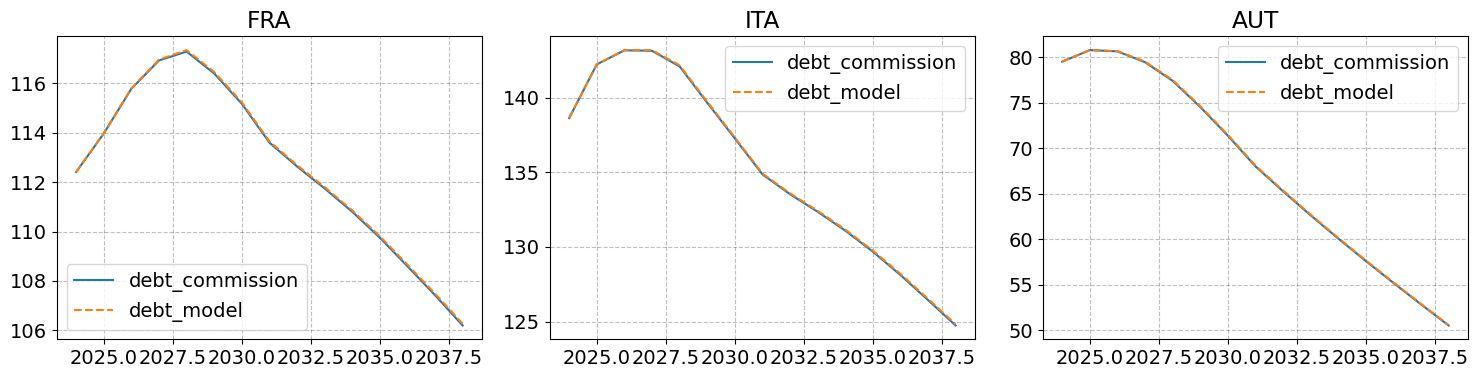

In [4]:
sheets = load_prior_guidance(EU27, vintage='2024')

def replicate_adjustment_scenario(country, input_file='dsa_inputs_commission_2024.xlsx'):
    sheet = sheets[country]
    T = sheet.T
    spb_path = sheet.row('Adjustment scenario', r'^Structural primary balance').loc[T:sheet.adjustment_end].to_numpy()
    model = DSA(country, input_file=input_file, adjustment_period=sheet.adjustment_end - T)
    model.project(spb_steps=np.diff(spb_path))
    return pd.DataFrame({
        'debt_commission': sheet.row('Adjustment scenario', r'^Gross debt'),
        'debt_model': model.df('d')['d'].droplevel('t'),
        'balance_commission': sheet.row('Adjustment scenario', r'^Headline balance'),
        'balance_model': model.df('ob')['ob'].droplevel('t'),
    }).loc[T:T + 14]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, country in zip(axes, ['FRA', 'ITA', 'AUT']):
    df = replicate_adjustment_scenario(country)
    df[['debt_commission', 'debt_model']].plot(ax=ax, style=['-', '--'], title=country)
plt.tight_layout()

In [5]:
# Maximum absolute difference in debt and headline balance to T+14 (pp. of GDP) for all countries
pd.DataFrame({
    c: {'debt': (d['debt_model'] - d['debt_commission']).abs().max(),
        'balance': (d['balance_model'] - d['balance_commission']).abs().loc[sheets[c].T + 1:].max()}
    for c in EU27 for d in [replicate_adjustment_scenario(c)]
}).T.round(3).T

,AUT,BEL,BGR,HRV,CYP,CZE,DNK,EST,FIN,FRA,DEU,GRC,HUN,IRL,ITA,LVA,LTU,LUX,MLT,NLD,POL,PRT,ROU,SVK,SVN,ESP,SWE
debt,0.10,0.10,0.01,0.03,0.03,0.00,9.94,0.00,0.06,0.07,0.04,0.02,0.06,0.11,0.08,0.01,0.01,0.00,0.07,0.00,0.07,0.23,0.10,0.09,0.02,0.08,0.02
balance,0.03,0.03,0.00,0.01,0.00,0.00,0.22,0.00,0.02,0.02,0.01,0.00,0.02,0.02,0.02,0.00,0.00,0.00,0.02,0.00,0.02,0.04,0.03,0.03,0.01,0.02,0.00


- Debt paths match within about 0.1 pp. of GDP over 14 years for almost all countries.
- **Denmark** is the exception: the Commission projects a negative debt ratio from 2034, while the model floors debt at zero.

## Reference trajectory

- `find_spb_binding(rules='commission')` applies the procedure of the Commission prior guidance sheets:
  1. **DSA-based adjustment**: smallest constant annual SPB step such that debt declines over 10 years after the adjustment period in the adjustment, lower SPB, financial stress and adverse r-g scenarios, debt declines with 70% probability over 5 years (stochastic), and the deficit stays below 3% of GDP for 10 years after the adjustment; alternatively, the deficit criterion holds and debt is below 60% ten years after the adjustment in all scenarios.
  2. **Safeguards**: the smallest annual step above the DSA-based one that meets the debt sustainability safeguard on the path including the deficit benchmark (min. 0.5 pp. under EDP while the deficit exceeds 3%, in structural terms from 2028) and the deficit resilience safeguard (min. 0.4 pp., or 0.25 pp. with extension, while the structural deficit exceeds 1.5%).
- Countries with debt below 60% and a deficit below 3% receive technical information: the deficit criterion, debt below 60% and the deficit resilience safeguard apply.
- Results are displayed as tables and stored in `binding_tables`; the DSA-based and final annual adjustment are in `binding_parameter_dict`.

In [6]:
results = {}
for n in [4, 7]:
    model = DSA('FRA', input_file='dsa_inputs_commission_2024.xlsx', adjustment_period=n)
    np.random.seed(0)
    model.find_spb_binding(rules='commission', print_results=(n == 4))
    results[n] = {**model.binding_parameter_dict, 'spb_end': model.spb_target_dict['binding'], 'tables': model.binding_tables}

**Summary**

,FRA
Country,France
Adjustment period,2025-2028
Rules,commission
Guidance,reference trajectory
Binding criterion,Deficit below 3% (DSA)
SPB in T (% of GDP),-2.97
DSA-based SPB target (% of GDP),0.83
SPB at end of adjustment (% of GDP),0.83
Average annual adjustment (pp.),0.95
Average net expenditure growth (%),1.02


**SPB targets**

,SPB at end of adjustment,Average annual adjustment
Criterion,,
Deficit below 3% (DSA),0.81,0.94
Adjustment scenario: debt declines (DSA),-0.07,0.72
Adjustment scenario: debt below 60% (DSA),4.83,1.95
Lower SPB scenario: debt declines (DSA),0.37,0.83
Lower SPB scenario: debt below 60% (DSA),5.33,2.07
Financial stress scenario: debt declines (DSA),0.49,0.87
Financial stress scenario: debt below 60% (DSA),4.96,1.98
Adverse r-g scenario: debt declines (DSA),0.76,0.93
Adverse r-g scenario: debt below 60% (DSA),5.34,2.08


**Adjustment path**

,Annual SPB adjustment (pp.),EDP minimum step (pp.),Deficit resilience minimum step (pp.),SPB before change in ageing costs (% of GDP),Structural primary balance (% of GDP),Overall balance (% of GDP),Structural balance (% of GDP),Debt (% of GDP),Net expenditure growth (%)
Year,,,,,,,,,
2024,,,,-2.97,-2.97,-5.31,-5.00,112.41,
2025,0.95,0.50,0.40,-2.02,-2.02,-4.74,-4.37,113.97,1.32
2026,0.95,0.50,0.40,-1.07,-1.07,-4.27,-3.59,115.79,1.01
2027,0.95,0.50,0.40,-0.12,-0.12,-3.70,-2.80,116.94,0.89
2028,0.95,0.63,0.40,0.83,0.83,-3.03,-1.98,117.30,0.85
2029,0.00,,,0.83,0.86,-2.74,-2.04,116.37,2.64
2030,0.00,,,0.83,0.87,-2.44,-2.09,115.10,2.71
2031,0.00,,,0.83,0.89,-2.14,-2.14,113.47,2.80
2032,0.00,,,0.83,0.89,-2.19,-2.19,112.47,2.89


In [7]:
commission = sheets['FRA'].results()
pd.DataFrame({
    'Commission DSA-based annual adjustment': [commission['annual_adjustment_dsa_4y'], commission['annual_adjustment_dsa_7y']],
    'Model DSA-based annual adjustment': [results[4]['annual_adjustment_dsa'], results[7]['annual_adjustment_dsa']],
    'Commission SPB at end of adjustment': [commission['spb_end_4y'], commission['spb_end_7y']],
    'Model SPB at end of adjustment': [results[4]['spb_end'], results[7]['spb_end']],
}, index=['4-year', '7-year'])

,Commission DSA-based annual adjustment,Model DSA-based annual adjustment,Commission SPB at end of adjustment,Model SPB at end of adjustment
4-year,0.94,0.95,0.79,0.83
7-year,0.56,0.56,1.23,1.22


In [8]:
# Annual SPB step required by each criterion
pd.DataFrame({f'{n}-year': results[n]['tables']['SPB targets']['Average annual adjustment'] for n in [4, 7]})

,4-year,7-year
Criterion,,
Deficit below 3% (DSA),0.94,0.55
Adjustment scenario: debt declines (DSA),0.72,0.41
Adjustment scenario: debt below 60% (DSA),1.95,1.09
Lower SPB scenario: debt declines (DSA),0.83,0.47
Lower SPB scenario: debt below 60% (DSA),2.07,1.14
Financial stress scenario: debt declines (DSA),0.87,0.51
Financial stress scenario: debt below 60% (DSA),1.98,1.10
Adverse r-g scenario: debt declines (DSA),0.93,0.52
Adverse r-g scenario: debt below 60% (DSA),2.08,1.15


## All countries

- `data_pipeline.validate.compare_with_commission()` runs both comparisons for all countries (takes about 10 minutes with stochastic simulations). Results are saved in `output/validation`.

In [9]:
# from data_pipeline.validate import compare_with_commission
# summary, debt_paths = compare_with_commission('dsa_inputs_commission_2024.xlsx')

summary = pd.read_excel(REPO_ROOT / 'output' / 'validation' / 'commission_2024_comparison.xlsx', sheet_name='spb_targets')
summary[['country', 'guidance', 'adjustment_period', 'commission_annual_adjustment_dsa', 'model_annual_adjustment_dsa_rounded',
         'commission_spb_end', 'model_spb_end', 'diff_spb_end', 'model_binding_criterion']]

,country,guidance,adjustment_period,commission_annual_adjustment_dsa,model_annual_adjustment_dsa_rounded,commission_spb_end,model_spb_end,diff_spb_end,model_binding_criterion
0,AUT,reference trajectory,4,0.56,0.54,2.58,2.58,0.00,debt_safeguard
1,AUT,reference trajectory,7,0.32,0.28,1.88,1.88,0.00,debt_safeguard
2,BEL,reference trajectory,4,0.82,0.81,1.25,1.21,-0.04,debt_declines_adverse_r_g
3,BEL,reference trajectory,7,0.48,0.47,1.59,1.57,-0.02,debt_declines_adverse_r_g
4,BGR,technical information,4,NaN,0.00,-0.87,-0.89,-0.02,deficit_reduction
5,BGR,technical information,7,NaN,0.06,-0.53,-0.53,0.00,deficit_reduction
6,HRV,technical information,4,NaN,0.37,-0.36,-0.36,0.00,debt_below_60_main_adjustment
7,HRV,technical information,7,NaN,0.24,-0.21,-0.21,0.00,debt_below_60_main_adjustment
8,CYP,reference trajectory,4,0.00,0.00,3.48,3.48,0.00,floor
9,CYP,reference trajectory,7,0.00,0.00,3.48,3.48,0.00,floor


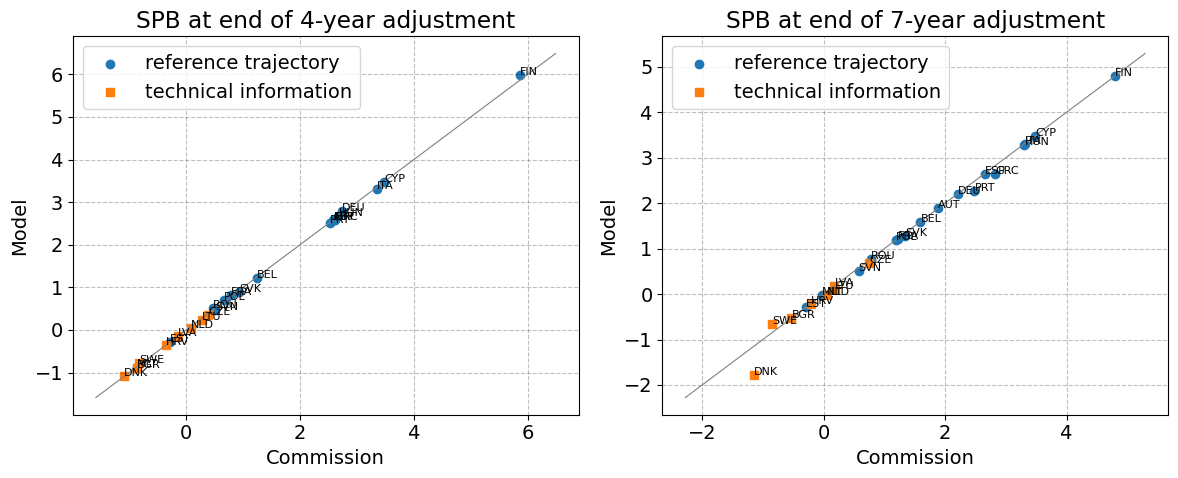

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, n in zip(axes, [4, 7]):
    df = summary.loc[summary['adjustment_period'] == n].dropna(subset=['commission_spb_end'])
    for guidance, marker in [('reference trajectory', 'o'), ('technical information', 's')]:
        d = df.loc[df['guidance'] == guidance]
        ax.scatter(d['commission_spb_end'], d['model_spb_end'], marker=marker, label=guidance)
        for _, r in d.iterrows():
            ax.annotate(r['country'], (r['commission_spb_end'], r['model_spb_end']), fontsize=8)
    lim = [df[['commission_spb_end', 'model_spb_end']].min().min() - 0.5, df[['commission_spb_end', 'model_spb_end']].max().max() + 0.5]
    ax.plot(lim, lim, color='grey', lw=0.8)
    ax.set_title(f'SPB at end of {n}-year adjustment')
    ax.set_xlabel('Commission'); ax.set_ylabel('Model'); ax.legend()
plt.tight_layout()

In [11]:
# Absolute differences in SPB at end of adjustment (pp. of GDP)
summary.assign(abs_diff=summary['diff_spb_end'].abs()).groupby(['guidance', 'adjustment_period'])['abs_diff'].describe()[['count', '50%', 'max']]

count  50%  max
guidance              adjustment_period                 
not found             4                   0.00  NaN  NaN
                      7                   0.00  NaN  NaN
reference trajectory  4                  17.00 0.04 0.12
                      7                  17.00 0.01 0.21
technical information 4                   8.00 0.03 0.06
                      7                   8.00 0.07 0.63

## Default rules vs. Commission rules

`find_spb_binding` has one implementation with two sets of rules. The default follows Darvas, Welslau and Zettelmeyer (2024); `rules='commission'` switches all rules to the Commission prior guidance version. Each rule can also be switched individually:

| Rule | Default: Darvas, Welslau and Zettelmeyer (2024) | Commission prior guidance sheets (`rules='commission'`) | Option |
|---|---|---|---|
| Adjustment path | Sequential: the DSA-based target is reached linearly; EDP and deficit resilience steps **front-load** the adjustment and later steps are reduced to keep the target | **Constant** annual adjustment; EDP and deficit resilience minimum steps are added on top where they bind | `frontloading` |
| DSA criteria | Per deterministic scenario: debt declines *or* is below 60%; deficit below 3% | Debt declines in *all* scenarios and stochastically, *or* debt below 60% in all scenarios; deficit below 3% (tolerance 0.05). Countries with debt < 60% and deficit < 3% get *technical information* (deficit and debt below 60% only) | `dsa_criteria` |
| Stochastic criterion | Debt declines, or is below 60%, with 70% probability | Debt declines with 70% probability | `stochastic_criteria` |
| EDP | Triggered by a projected deficit above 3% (or by `edp_countries`); 0.5 pp. SPB steps, then 0.5 pp. SB steps | EDP status in T from the input file; abrogated after two years with a deficit below 3%; min. 0.5 pp. step after a year with a deficit above 3% (in SB terms from 2028) | `edp` |
| Debt safeguard | Average decline from the year the EDP is projected to be abrogated (the year after the deficit falls below 3%, if it stays below 3%, as in the Commission sheets), or T without EDP, to the end of adjustment: 1 pp. if debt in T > 90%, 0.5 pp. otherwise | Debt band by start-of-year debt (> 90%, 60-90%), averaged over adjustment years outside the EDP | `debt_safeguard` |
| Deficit resilience | Steps raised (up to 0.4/0.25 pp.) until the structural deficit is below 1.5% in the same year | 0.4/0.25 pp. step after a year with a structural deficit above 1.55% | `deficit_resilience` |
| Precision | Exact SPB target | Annual adjustment rounded up to 0.01 pp.; floor of 0 pp. (reference trajectory) or -1 pp. (technical information) | `grid` |

Why the default differs: the default translates the legal text consistently across countries and allows front-loading of adjustment, which is closer to how plans are implemented in practice (e.g. adjustment under the EDP happens early and does not raise the end-of-period target). The Commission sheets use a simplified constant-step implementation. Each rule can be switched individually, e.g. `find_spb_binding(edp='commission', frontloading=False)`, or all at once with `rules='commission'`. Differences can be sizeable where the EDP or the safeguards bind, e.g. France with a 7-year adjustment in section 4 of `tutorial.ipynb`; `commission_replication.ipynb` compares the model with the Commission results.

In [12]:
# France, 4-year adjustment, Commission data: default rules, individual Commission rules, all Commission rules
configs = {
    'default': {},
    'Commission DSA criteria': {'dsa_criteria': 'commission', 'stochastic_criteria': ['debt_declines']},
    'Commission EDP and safeguards, no frontloading': {'edp': 'commission', 'debt_safeguard': 'commission',
                                                       'deficit_resilience': 'commission', 'frontloading': False},
    'Commission': {'rules': 'commission'},
}
comparison = {}
model = DSA('FRA', input_file='dsa_inputs_commission_2024.xlsx', adjustment_period=4)
for label, options in configs.items():
    np.random.seed(0)
    model.find_spb_binding(print_results=False, **options)
    comparison[label] = model.binding_tables['Summary'].iloc[:, 0]
pd.DataFrame(comparison).loc[['Binding criterion', 'SPB at end of adjustment (% of GDP)', 'Average annual adjustment (pp.)',
                              'EDP binding', 'Debt safeguard binding', 'Deficit resilience binding']]

,default,Commission DSA criteria,"Commission EDP and safeguards, no frontloading",Commission
Binding criterion,Deficit below 3% (DSA),Deficit below 3% (DSA),Deficit below 3% (DSA),Deficit below 3% (DSA)
SPB at end of adjustment (% of GDP),0.87,0.87,0.87,0.83
Average annual adjustment (pp.),0.96,0.96,0.96,0.95
EDP binding,False,True,False,False
Debt safeguard binding,False,False,False,False
Deficit resilience binding,False,False,False,False


## Notes on differences

**Reproduced Commission conventions** (all set through the input workbook, not hard-coded):
- *Forecast years*: the implicit interest rate follows the forecast up to the last forecast year (T+1 for spring, T+2 for autumn forecasts) and is projected thereafter. In forecast years, only the deviation from the forecast output gap decays after an SPB change.
- *Multiplier*: SPB changes lower growth by the multiplier (0.75; 0.6 in guidance issued from 2025) in the year of the change; the resulting output gap closes by 1/3 per year. Without SPB changes, growth follows the baseline.
- *Market rates and inflation*: linear convergence to T+10 (Bloomberg forward rates, inflation swaps) and T+30 anchors.
- *One-off measures* enter the primary balance but not the SPB; *stock-flow adjustments* include exchange rate effects.
- *Greece*: the Commission adds the difference between its Stata model and the Excel approximation to the implicit interest rate (up to 0.5 pp.), provided as `IMPLICIT_INTEREST_RATE_ADJ`.
- *Adjustments* are rounded up to the next 0.01 pp.; reference trajectories are non-negative, technical information allows at most -1 pp. per year.
- *Debt safeguard*: debt bands (above 90%, 60-90%) refer to the debt ratio at the start of each year; the average excludes years under EDP.

**Remaining differences** are small in most cases and plausible given that the model translates the legal rules consistently across countries:
- *Stochastic criterion*: the model uses its own historical shock data (Eurostat, OECD, ECB, up to 2026), the Commission uses its Stata simulations. This explains e.g. Finland (4-year).
- *Denmark*: the model floors the debt ratio at zero.
- *Technical information with 7-year adjustment* (e.g. Sweden, Denmark) and the *updated Hungarian guidance*: the Commission's out-year projections are not published in the sheets, so these cannot be traced in detail.
- *Portugal and Greece (7-year)*: the model requires a somewhat smaller adjustment. The debt paths under the Commission SPB path match closely, and the binding criterion (debt declines in the adverse r-g scenario after the adjustment period) is the same, so the difference arises in the out-years beyond the horizon published in the sheets and cannot be traced in detail.
- *Ireland and Luxembourg* (2024) received technical information in a format without reported targets.

## Latest data

- By default, the model uses the **latest input workbook built from public APIs** (AMECO forecast via DBnomics, ECB, ESM, Ageing Report, DSM fiches, historical shocks from Eurostat, OECD and ECB), with market anchors from the latest Commission guidance, a multiplier of 0.75 and a **persistent multiplier effect** on the output gap.
- `find_spb_binding()` applies the default rules (Darvas, Welslau and Zettelmeyer 2024) to these data, `find_spb_binding(rules='commission')` the Commission rules.

In [13]:
model = DSA('FRA')
print(f'Input file: {model.input_file}, start year: {model.start_year}, multiplier: {model.fiscal_multiplier} ({model.fiscal_multiplier_type})')
np.random.seed(0)
model.find_spb_binding()

Input file: dsa_inputs_2026_09.xlsx, start year: 2026, multiplier: 0.75 (pers)


**Summary**

,FRA
Country,France
Adjustment period,2027-2030
Rules,default
Binding criterion,Deficit below 3% (DSA)
SPB in T (% of GDP),-1.97
DSA-based SPB target (% of GDP),1.15
SPB at end of adjustment (% of GDP),1.15
Average annual adjustment (pp.),0.78
Average net expenditure growth (%),1.66
EDP abrogation year (projected),2031


**SPB targets**

,SPB at end of adjustment,Average annual adjustment
Criterion,,
Adjustment scenario: debt declines or below 60% (DSA),-0.29,0.42
Lower SPB scenario: debt declines or below 60% (DSA),0.32,0.57
Financial stress scenario: debt declines or below 60% (DSA),-0.05,0.48
Adverse r-g scenario: debt declines or below 60% (DSA),0.58,0.64
Deficit below 3% (DSA),1.15,0.78
Stochastic (DSA),0.21,0.54
Binding,1.15,0.78


**Adjustment path**

,Annual SPB adjustment (pp.),EDP minimum step (pp.),SPB before change in ageing costs (% of GDP),Structural primary balance (% of GDP),Overall balance (% of GDP),Structural balance (% of GDP),Debt (% of GDP),Net expenditure growth (%)
Year,,,,,,,,
2026,,,-1.97,-1.97,-5.11,-4.55,118.05,
2027,0.78,0.50,-1.19,-1.19,-5.09,-4.01,120.64,1.57
2028,0.78,0.50,-0.41,-0.41,-4.56,-3.43,121.69,1.63
2029,0.78,0.50,0.37,0.37,-3.87,-2.81,121.72,1.68
2030,0.78,,1.15,1.15,-3.00,-2.14,120.58,1.74
2031,0.00,,1.15,1.16,-2.54,-2.17,118.40,3.22
2032,0.00,,1.15,1.16,-2.33,-2.21,116.49,3.27
2033,0.00,,1.15,1.12,-2.27,-2.27,114.75,3.32
2034,0.00,,1.15,1.07,-2.34,-2.34,113.30,3.38
